In [1]:
import sys
sys.path.append('..') 
from model_architectures import *
import numpy as np
import pandas as pd
from skimage.feature import hog
from sklearn.model_selection import train_test_split
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, OneCycleLR
from collections import Counter

from collections import Counter

C:\Users\Sai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# Enable GPU usage for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(f"Using device: {device}")
data = pd.read_csv("../archive/ascii_character_classification.csv", header=0)

label_counts = Counter(data.iloc[:, 0])
print(label_counts)

Using device: cuda
Counter({0: 50000, 4: 4959, 84: 4882, 15: 4870, 65: 4861, 88: 4844, 46: 4838, 45: 4836, 27: 4835, 23: 4824, 90: 4823, 55: 4815, 34: 4812, 72: 4808, 6: 4805, 10: 4799, 9: 4797, 30: 4797, 17: 4795, 75: 4794, 89: 4793, 47: 4792, 93: 4792, 33: 4789, 20: 4784, 14: 4784, 13: 4782, 32: 4778, 50: 4776, 78: 4772, 94: 4771, 11: 4761, 54: 4761, 43: 4759, 73: 4759, 31: 4758, 29: 4754, 60: 4753, 63: 4751, 68: 4749, 26: 4749, 58: 4749, 28: 4746, 92: 4746, 82: 4744, 38: 4744, 37: 4742, 67: 4736, 87: 4736, 21: 4734, 70: 4732, 91: 4732, 77: 4728, 16: 4726, 95: 4725, 79: 4724, 66: 4722, 61: 4720, 81: 4720, 12: 4716, 59: 4715, 48: 4711, 74: 4710, 71: 4710, 69: 4709, 53: 4706, 44: 4706, 76: 4705, 56: 4705, 42: 4698, 1: 4698, 18: 4697, 36: 4694, 85: 4692, 19: 4690, 57: 4690, 41: 4688, 24: 4687, 40: 4680, 35: 4676, 83: 4673, 25: 4673, 8: 4668, 62: 4655, 3: 4645, 86: 4641, 5: 4640, 22: 4638, 39: 4632, 80: 4625, 7: 4624, 52: 4618, 64: 4614, 2: 4606, 51: 4602, 49: 4596})


In [3]:
X = data.iloc[:, 1:].astype("float64")   # Features are all columns except the first one
y = data.iloc[:, 0].astype("float64")     # Labels are the first column

def extract_hog_features(images):
    hog_features = []
    for image in images:
        image_reshaped = image.reshape((10, 10))
        features = hog(image_reshaped, pixels_per_cell=(2, 2), cells_per_block=(1, 1), feature_vector=True)
        hog_features.append(features)
    return np.array(hog_features)

X_hog = extract_hog_features(np.array(X))

X_train, X_test, y_train, y_test = train_test_split(X_hog, y, test_size=0.2, random_state=42)


In [4]:

X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32)
y_test_tensor = torch.tensor(np.array(y_test), dtype=torch.long)

train_data = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_data, batch_size=2048, shuffle=False)

test_data = TensorDataset(X_train_tensor, y_train_tensor)
test_loader = DataLoader(train_data, batch_size=2048, shuffle=False)


input_features = 225
output_classes = 96

In [5]:
model = NeuralNetwork(input_features, 128, 64, 32, output_classes)
model.to(device)

NeuralNetwork(
  (fc1): Linear(in_features=225, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=96, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)

In [6]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-1)
# scheduler = StepLR(optimizer, step_size=5, gamma=0.5)  # Adjust step_size and gamma as needed

# Compute Train Accuracy
def compute_accuracy(model, data_loader, device):
    correct_pred, num_examples = 0, 0
    for features, targets in data_loader:
        features = features.to(device)
        targets = targets.to(device)
        outputs = model(features)
        _, predicted_labels = torch.max(outputs, 1)
        num_examples += targets.size(0)
        correct_pred += (predicted_labels == targets).sum().item()
    return correct_pred / num_examples * 100

In [7]:
num_epochs = 100

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (features, labels) in enumerate(train_loader):
        optimizer.zero_grad()

        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss / 100:.4f}')
            running_loss = 0.0

    # scheduler.step()

    train_accuracy = compute_accuracy(model, train_loader, device)
    print(f'Epoch [{epoch+1}/{num_epochs}], Training Accuracy: {train_accuracy:.2f}%')

    # Save losses and accuracies
    train_losses.append(running_loss)
    train_accuracies.append(train_accuracy)

print('Training finished.')

Epoch [1/100], Step [100/196], Loss: 4.4841
Epoch [1/100], Training Accuracy: 9.99%
Epoch [2/100], Step [100/196], Loss: 4.4815
Epoch [2/100], Training Accuracy: 9.99%
Epoch [3/100], Step [100/196], Loss: 4.4815
Epoch [3/100], Training Accuracy: 9.99%
Epoch [4/100], Step [100/196], Loss: 4.4815
Epoch [4/100], Training Accuracy: 9.99%
Epoch [5/100], Step [100/196], Loss: 4.4815
Epoch [5/100], Training Accuracy: 9.99%
Epoch [6/100], Step [100/196], Loss: 4.4815
Epoch [6/100], Training Accuracy: 9.99%
Epoch [7/100], Step [100/196], Loss: 4.4815
Epoch [7/100], Training Accuracy: 9.99%
Epoch [8/100], Step [100/196], Loss: 4.4815
Epoch [8/100], Training Accuracy: 9.99%
Epoch [9/100], Step [100/196], Loss: 4.4815
Epoch [9/100], Training Accuracy: 9.99%
Epoch [10/100], Step [100/196], Loss: 4.4815
Epoch [10/100], Training Accuracy: 9.99%
Epoch [11/100], Step [100/196], Loss: 4.4815
Epoch [11/100], Training Accuracy: 9.99%
Epoch [12/100], Step [100/196], Loss: 4.4815
Epoch [12/100], Training Ac

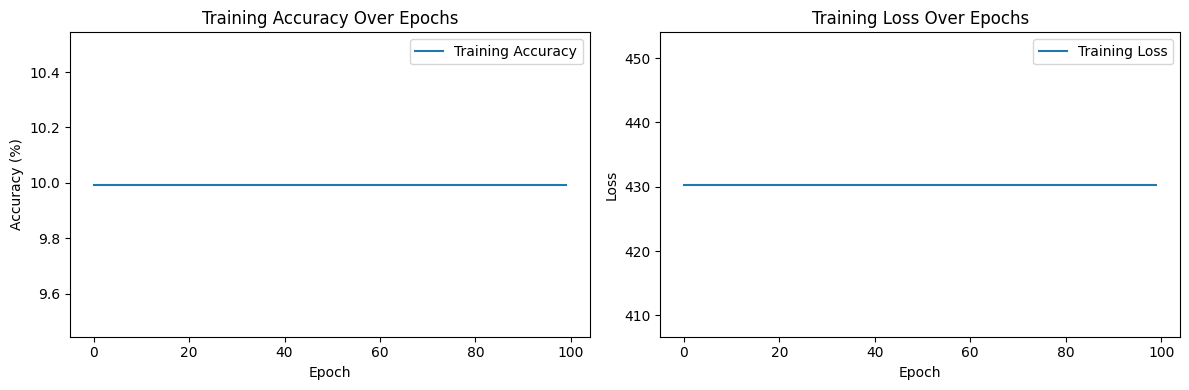

In [8]:
# Plotting training accuracies and losses
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Training Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
torch.save(model.state_dict(), f'../artifacts/nn_ascii_classifier.pth')

In [10]:
model.eval()

correct = 0
total = 0


with torch.no_grad():
    for i, (features, labels) in enumerate(test_loader):
        optimizer.zero_grad()

        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)
        probabilities = F.softmax(outputs, dim=1)
        
        _, predicted = torch.max(probabilities, 1)

        

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        


    
accuracy = correct / total
print(f'Test Accuracy: {accuracy * 100:.4f}%')

Test Accuracy: 9.9940%
